# STUDENT MENTAL HEALTH FACTORS & ACADEMIC PERFORMANCE


This project investigates whether student stress, mental health, sleep quality,
social support, and self-esteem can be used to predict low academic performance.

The analysis includes data cleaning, exploratory data analysis,feature engineering,and classification using Logistic Regression and K-Nearest Neighbors (KNN).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

 Load and Audit the Dataset

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/mibur1/psy111/main/book/statistics/4_Moderated_Reg/data/StressLevelDataset.csv"

df = pd.read_csv(DATA_URL)

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


Data Audit

In [ ]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

First 5 rows:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1



Last 5 rows:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
1095,11,17,0,14,3,1,3,2,2,2,...,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,...,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,...,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,...,1,2,5,1,4,1,4,4,4,2
1099,18,6,1,15,3,3,0,3,3,0,...,3,3,4,3,3,1,5,1,4,2



Dataset shape:
(1100, 21)

Column names:
['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']

Data types:
anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relatio

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000



Missing values:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

Duplicate rows:
0


Data Cleaning

In [ ]:
# Dropped columns that are not required for the analysis
df = df.drop(columns=["blood_pressure", "headache"])

# Filled missing numeric values with the median
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

# Removed duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# Created mental health score
df["mental_health_score"] = (
    df["depression"] + df["anxiety_level"]
) / 2

# Created binary target for low academic performance
df["low_performance"] = (
    df["academic_performance"] <= 2
).astype(int)

# Removed the original academic performance column
df = df.drop(columns=["academic_performance"])

print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

display(df.head())

Final dataset shape: (1100, 20)

Missing values:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
mental_health_score             0
low_performance                 0
dtype: int64

Duplicate rows:
0


,anxiety_level,self_esteem,mental_health_history,depression,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level,mental_health_score,low_performance
0,14,20,0,11,2,4,2,3,3,2,2,3,3,2,3,3,2,1,12.5,0
1,15,8,1,15,1,4,3,1,2,2,4,1,5,1,4,5,5,2,15.0,1
2,12,18,1,14,2,2,2,2,3,2,3,3,2,2,3,2,2,1,13.0,1
3,16,12,1,15,1,3,4,2,2,2,4,1,4,1,4,4,5,2,15.5,1
4,16,28,0,7,5,1,3,2,4,3,3,1,2,1,5,0,5,1,11.5,0


#Exploratory Data Analysis

Academic Performance Distribution

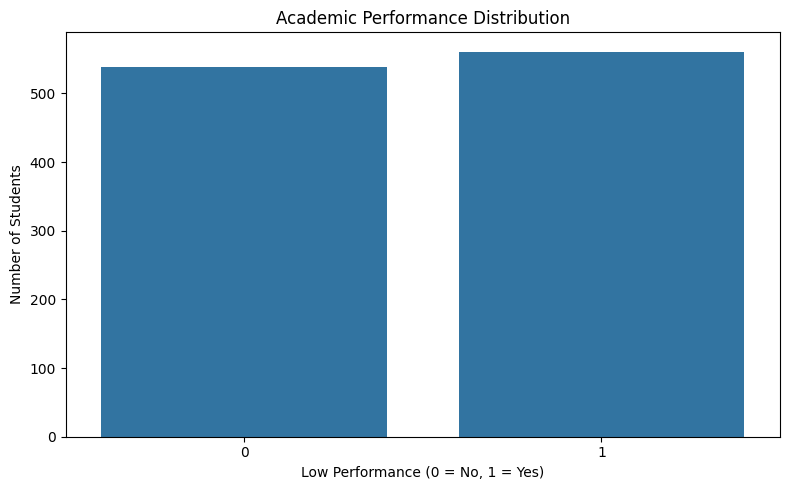

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="low_performance"
)

plt.title("Academic Performance Distribution")
plt.xlabel("Low Performance (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

 Average Stress Level by Performance Group

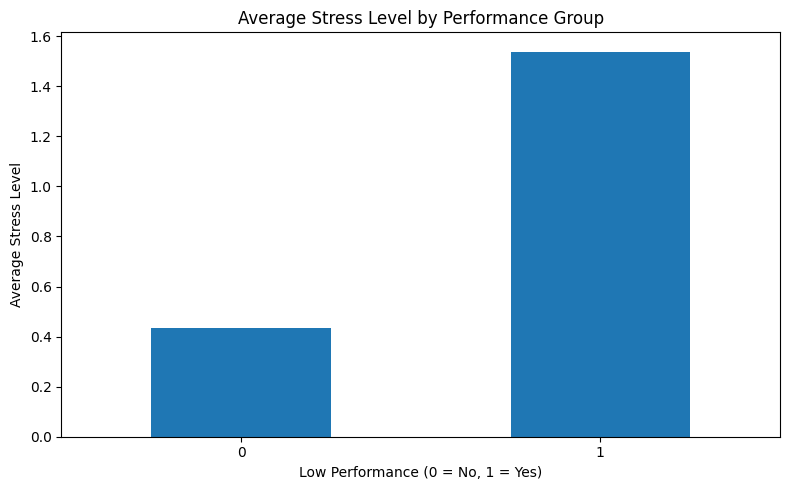

In [ ]:
stress_by_group = df.groupby("low_performance")["stress_level"].mean()

plt.figure(figsize=(8, 5))

stress_by_group.plot(kind="bar")

plt.title("Average Stress Level by Performance Group")
plt.xlabel("Low Performance (0 = No, 1 = Yes)")
plt.ylabel("Average Stress Level")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 Average Sleep Quality by Performance Group

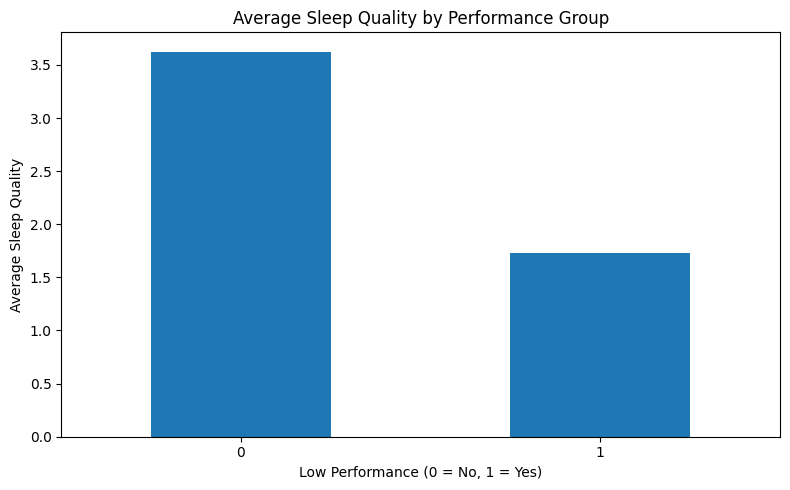

In [ ]:
sleep_by_group = df.groupby("low_performance")["sleep_quality"].mean()

plt.figure(figsize=(8, 5))

sleep_by_group.plot(kind="bar")

plt.title("Average Sleep Quality by Performance Group")
plt.xlabel("Low Performance (0 = No, 1 = Yes)")
plt.ylabel("Average Sleep Quality")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 Depression and Anxiety by Performance Group

<Figure size 800x500 with 0 Axes>

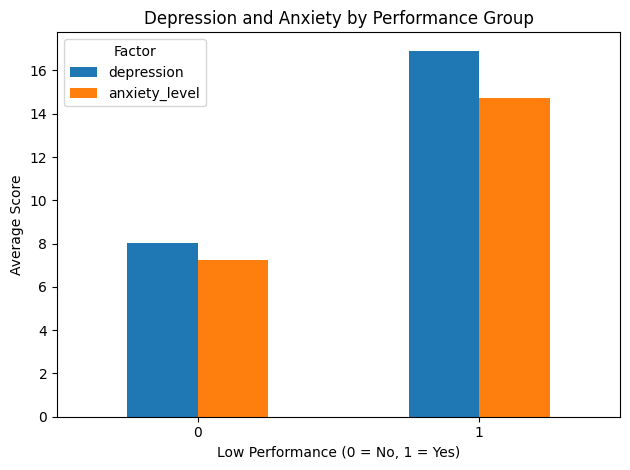

In [ ]:
mental_health_by_group = df.groupby("low_performance")[
    ["depression", "anxiety_level"]
].mean()

plt.figure(figsize=(8, 5))

mental_health_by_group.plot(kind="bar")

plt.title("Depression and Anxiety by Performance Group")
plt.xlabel("Low Performance (0 = No, 1 = Yes)")
plt.ylabel("Average Score")

plt.xticks(rotation=0)
plt.legend(title="Factor")

plt.tight_layout()
plt.show()

#Features and Target

In [10]:
features = [
    "stress_level",
    "mental_health_score",
    "sleep_quality",
    "social_support",
    "self_esteem"
]

X = df[features]
y = df["low_performance"]

print("Features:")
print(features)

print("\nTarget distribution:")
print(y.value_counts())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['stress_level', 'mental_health_score', 'sleep_quality', 'social_support', 'self_esteem']

Target distribution:
low_performance
1    561
0    539
Name: count, dtype: int64

X shape: (1100, 5)
y shape: (1100,)


#Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (825, 5)
Testing set: (275, 5)


#Model Development


In [12]:
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

print("KNN and Logistic Regression pipelines created.")

KNN and Logistic Regression pipelines created.


6. Model Selection Using 5-Fold Cross-Validation

In [13]:
knn_cv_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

logistic_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("KNN balanced accuracy:")
print(knn_cv_scores)
print("KNN mean:", knn_cv_scores.mean())

print("\nLogistic Regression balanced accuracy:")
print(logistic_cv_scores)
print("Logistic Regression mean:", logistic_cv_scores.mean())

KNN balanced accuracy:
[0.76212522 0.74955908 0.75749559 0.71957672 0.75919118]
KNN mean: 0.7495895580454404

Logistic Regression balanced accuracy:
[0.8053351  0.79872134 0.77116402 0.73236332 0.77279412]
Logistic Regression mean: 0.7760755783795


# Final Model Evaluation

In [14]:
# Fit both models
knn_pipeline.fit(X_train, y_train)
logistic_pipeline.fit(X_train, y_train)

# Predictions
knn_predictions = knn_pipeline.predict(X_test)
logistic_predictions = logistic_pipeline.predict(X_test)

# Baseline model
baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


#Performance Comparison

In [15]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_predictions),
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, knn_predictions)
    ],
    "Precision": [
        precision_score(y_test, baseline_predictions),
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, knn_predictions)
    ],
    "Recall": [
        recall_score(y_test, baseline_predictions),
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, knn_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_predictions),
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, knn_predictions)
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.509091,0.509091,1.000000,0.674699
1,Logistic Regression,0.763636,0.758621,0.785714,0.771930
2,KNN,0.756364,0.738562,0.807143,0.771331


#Classification Reports

In [16]:
print("Baseline Classification Report")
print(
    classification_report(
        y_test,
        baseline_predictions
    )
)

print("\nLogistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

print("\nKNN Classification Report")
print(
    classification_report(
        y_test,
        knn_predictions
    )
)

Baseline Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       135
           1       0.51      1.00      0.67       140

    accuracy                           0.51       275
   macro avg       0.25      0.50      0.34       275
weighted avg       0.26      0.51      0.34       275


Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       135
           1       0.76      0.79      0.77       140

    accuracy                           0.76       275
   macro avg       0.76      0.76      0.76       275
weighted avg       0.76      0.76      0.76       275


KNN Classification Report
              precision    recall  f1-score   support

           0       0.78      0.70      0.74       135
           1       0.74      0.81      0.77       140

    accuracy                           0.76       275
   macro avg       0.76    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrices

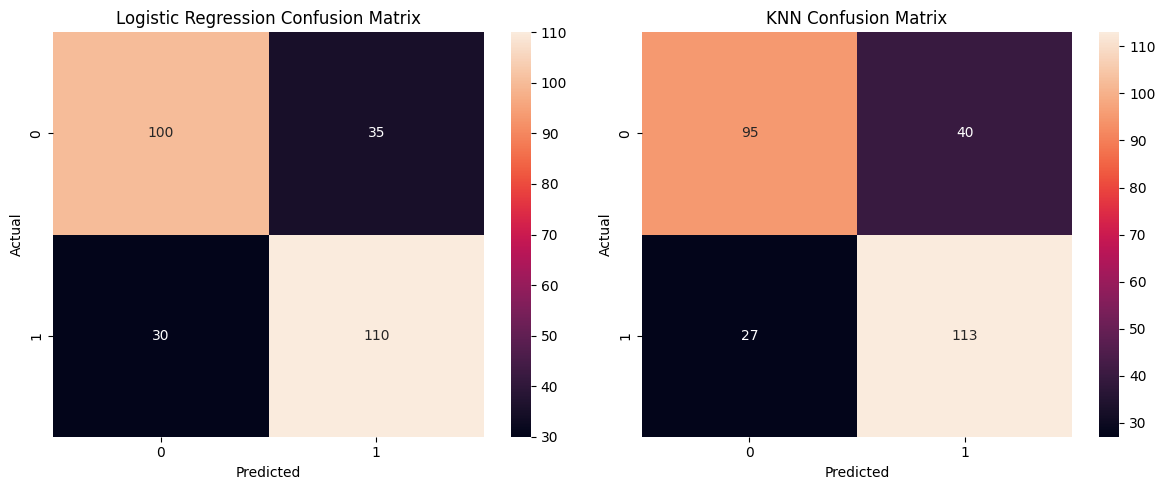

In [17]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

cm_knn = confusion_matrix(
    y_test,
    knn_predictions
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title("KNN Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

F1 Comparison of models

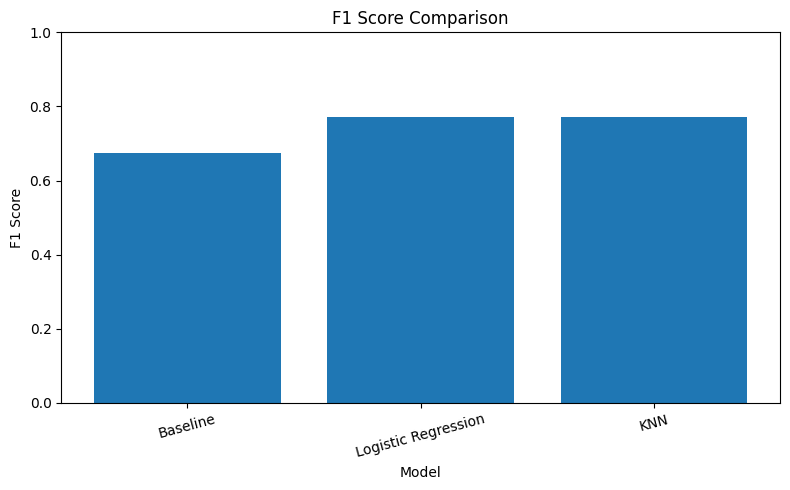

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Conclusion
Logistic Regression achieved a slightly higher overall performance than KNN.
It achieved an accuracy of approximately 76.4% and an F1 score of approximately
77.2% on the test set.

KNN produced a very similar F1 score of approximately 77.1%, while the baseline
model performed substantially worse.

The results suggest that stress level, mental health, sleep quality, social
support, and self-esteem contain useful information for identifying students
with low academic performance. However, the difference between Logistic
Regression and KNN was very small, so neither model can be considered
dramatically better than the other based on these results alone.